In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import os

print(os.getcwd())


c:\Users\DELL\Desktop\apexplanet-data-analytics\notebooks


In [4]:
df = pd.read_csv("../data/processed/ecommerce_sales_cleaned.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (4851, 17)


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1.0,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1.0,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1.0,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1.0,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1.0,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [5]:
df["order_date"] = pd.to_datetime(df["order_date"])

print("Date column converted successfully!")
print(df["order_date"].dtype)

Date column converted successfully!
datetime64[us]


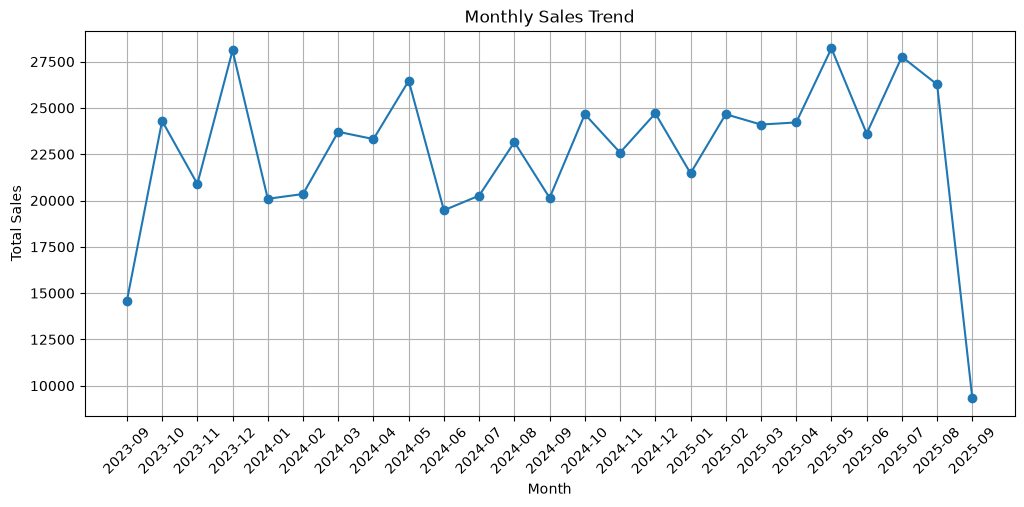

In [6]:
# Calculate monthly sales
monthly_sales = df.groupby(
    df["order_date"].dt.to_period("M")
)["total_amount"].sum()

# Convert period to string for plotting
monthly_sales.index = monthly_sales.index.astype(str)

# Create line chart
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

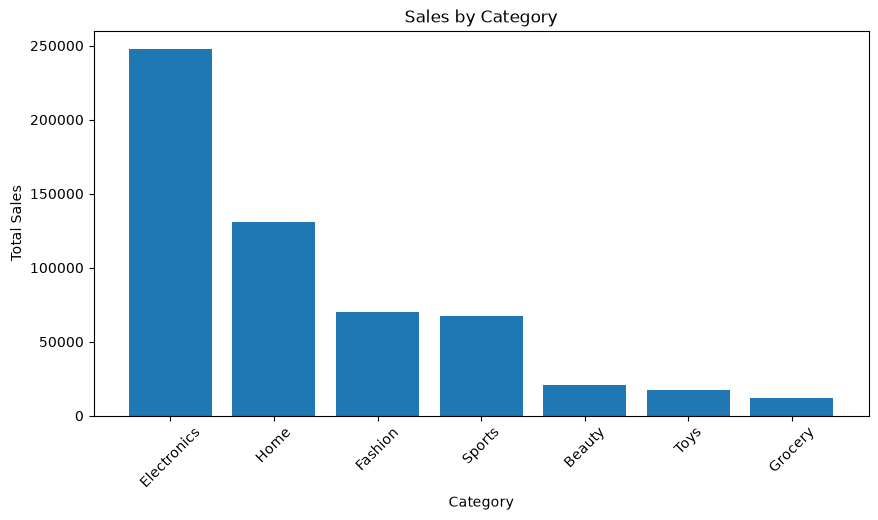

In [7]:
# Calculate sales by category
category_sales = df.groupby("category")["total_amount"].sum().sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(10, 5))
plt.bar(category_sales.index, category_sales.values)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

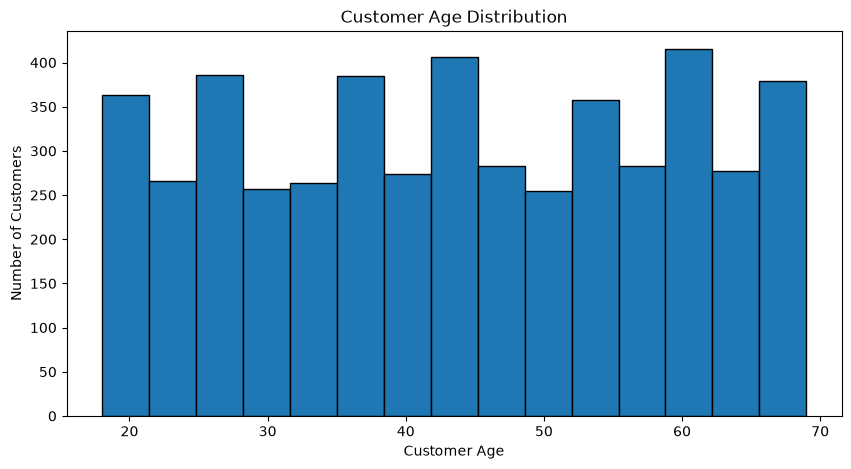

In [8]:
# Create histogram of customer ages
plt.figure(figsize=(10, 5))

plt.hist(df["customer_age"], bins=15, edgecolor="black")

plt.title("Customer Age Distribution")
plt.xlabel("Customer Age")
plt.ylabel("Number of Customers")

plt.show()


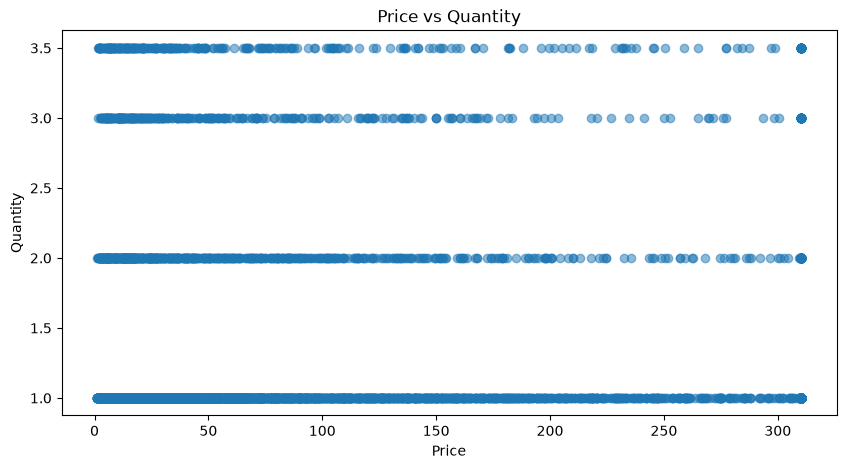

In [9]:
# Scatter plot: Price vs Quantity
plt.figure(figsize=(10, 5))

plt.scatter(df["price"], df["quantity"], alpha=0.5)

plt.title("Price vs Quantity")
plt.xlabel("Price")
plt.ylabel("Quantity")

plt.show()

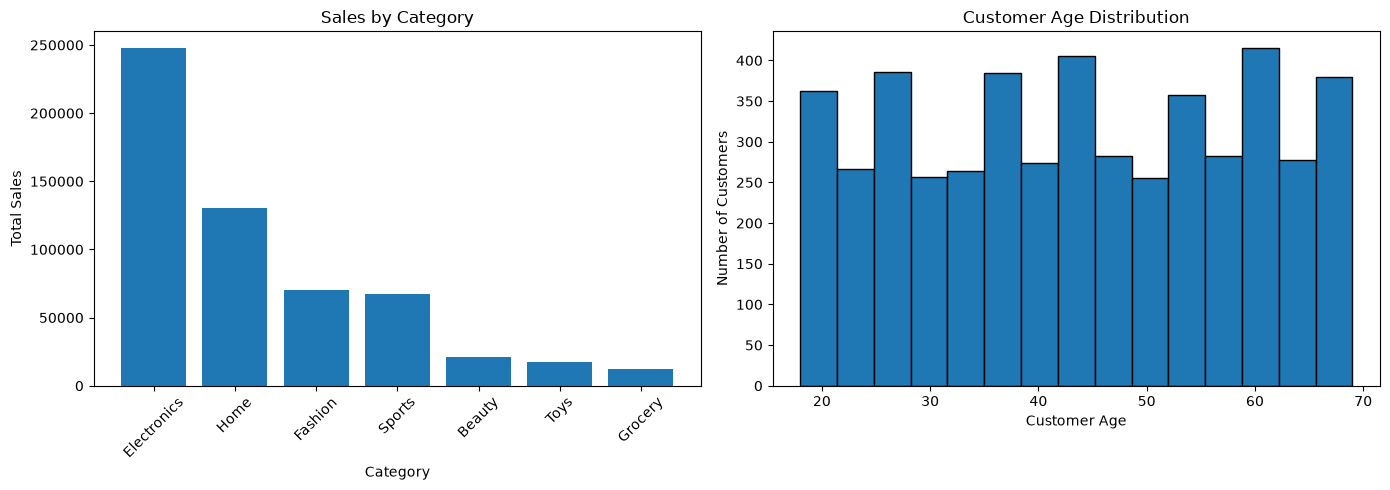

In [10]:
# Create multiple plots in one figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sales by category
axes[0].bar(category_sales.index, category_sales.values)
axes[0].set_title("Sales by Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Total Sales")
axes[0].tick_params(axis="x", rotation=45)

# Plot 2: Customer age distribution
axes[1].hist(df["customer_age"], bins=15, edgecolor="black")
axes[1].set_title("Customer Age Distribution")
axes[1].set_xlabel("Customer Age")
axes[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

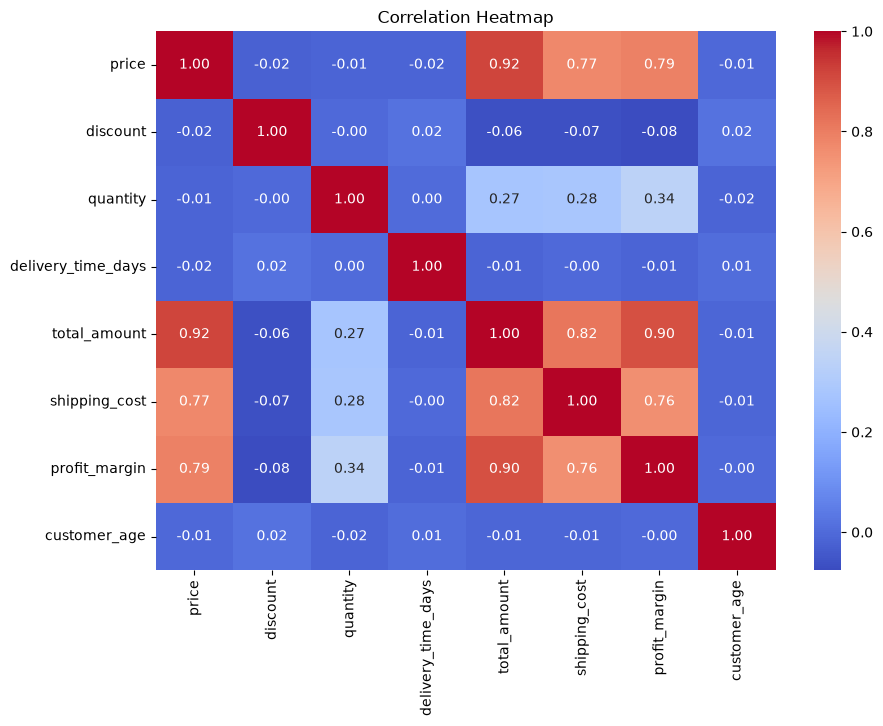

In [11]:
# Select numerical columns
numeric_cols = [
    "price",
    "discount",
    "quantity",
    "delivery_time_days",
    "total_amount",
    "shipping_cost",
    "profit_margin",
    "customer_age"
]

# Calculate correlation matrix
correlation = df[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

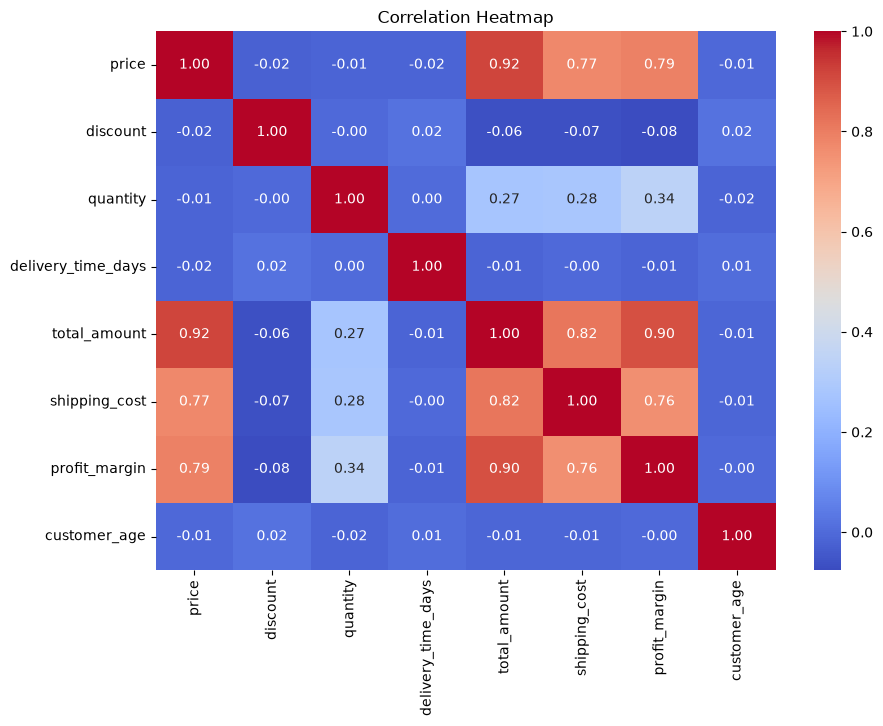

In [12]:
# Select numerical columns
numeric_cols = [
    "price",
    "discount",
    "quantity",
    "delivery_time_days",
    "total_amount",
    "shipping_cost",
    "profit_margin",
    "customer_age"
]

# Calculate correlation matrix
correlation = df[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

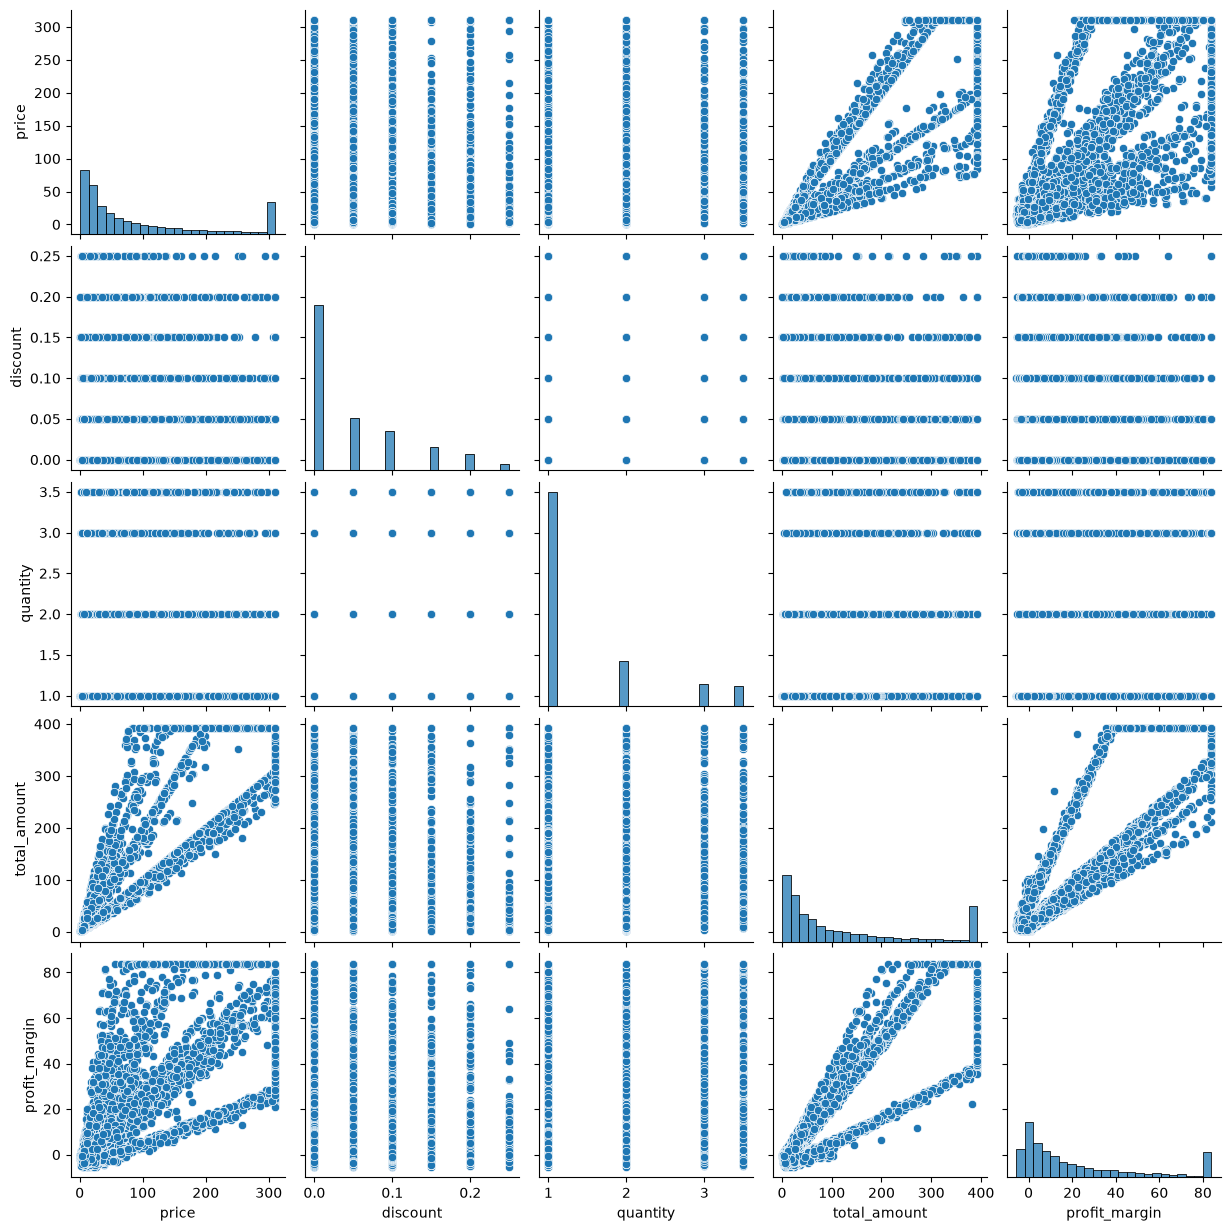

In [13]:
# Select important numerical columns
pairplot_data = df[
    ["price", "discount", "quantity", "total_amount", "profit_margin"]
]

# Create pairplot
sns.pairplot(pairplot_data)

plt.show()

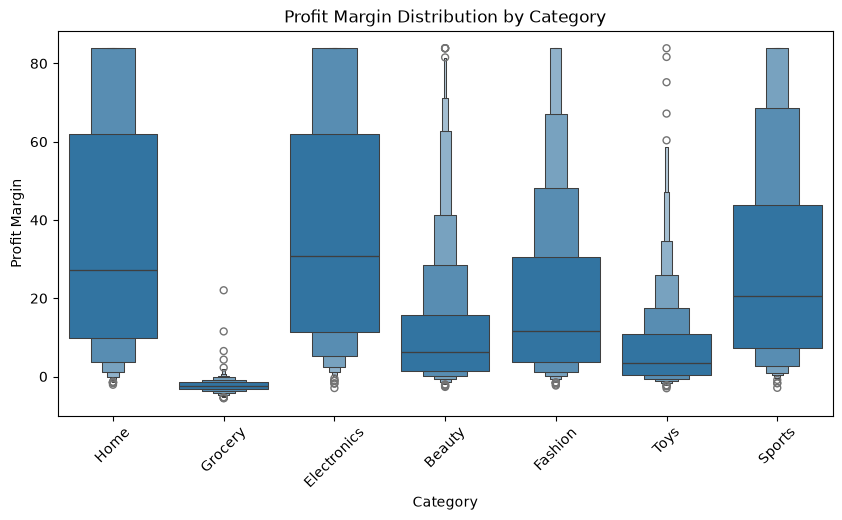

In [14]:
# Boxen plot for profit margin by category
plt.figure(figsize=(10, 5))

sns.boxenplot(
    data=df,
    x="category",
    y="profit_margin"
)

plt.title("Profit Margin Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin")
plt.xticks(rotation=45)

plt.show()

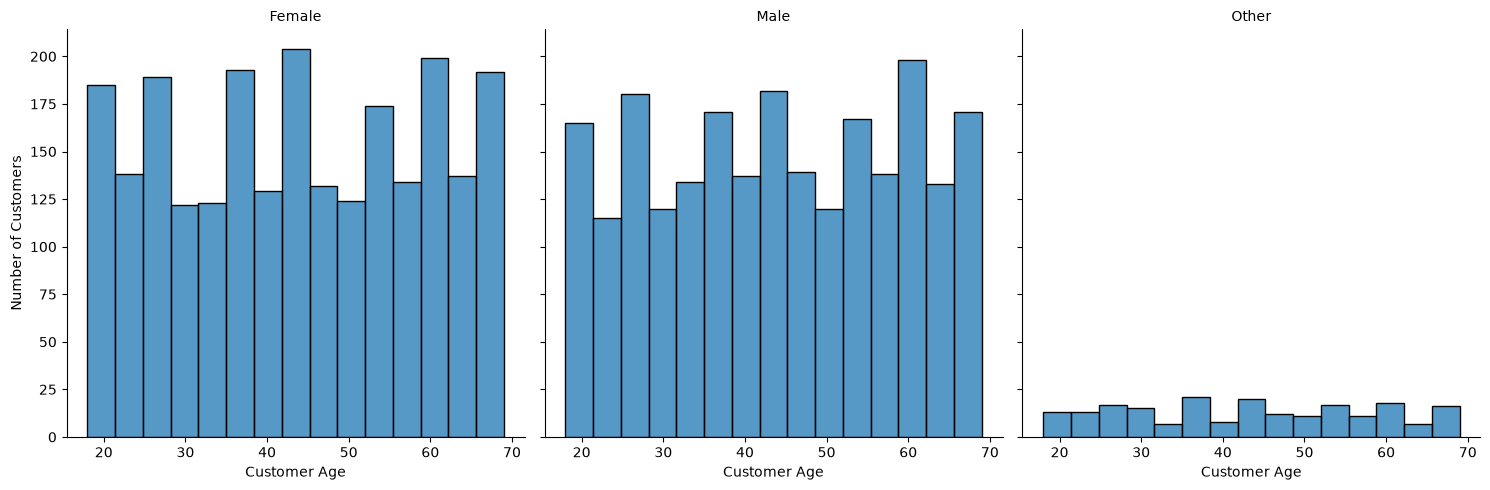

In [15]:
# Create FacetGrid by customer gender
g = sns.FacetGrid(
    df,
    col="customer_gender",
    height=5
)

g.map_dataframe(
    sns.histplot,
    x="customer_age",
    bins=15
)

g.set_axis_labels("Customer Age", "Number of Customers")
g.set_titles("{col_name}")

plt.show()

In [16]:
# Create an interactive sales chart
fig = px.bar(
    df.groupby("category", as_index=False)["total_amount"].sum(),
    x="category",
    y="total_amount",
    title="Interactive Sales by Category",
    labels={
        "category": "Category",
        "total_amount": "Total Sales"
    }
)

fig.show()

In [17]:
# Prepare daily sales data
daily_sales = (
    df.groupby("order_date", as_index=False)["total_amount"]
      .sum()
      .sort_values("order_date")
)

# Create interactive line chart with range slider
fig = px.line(
    daily_sales,
    x="order_date",
    y="total_amount",
    title="Daily Sales Trend",
    labels={
        "order_date": "Order Date",
        "total_amount": "Total Sales"
    }
)

# Add range slider
fig.update_xaxes(rangeslider_visible=True)

fig.show()

In [18]:
# Save the interactive Plotly chart
fig.write_html("../reports/daily_sales_interactive.html")

print("Interactive chart saved successfully!")

Interactive chart saved successfully!


In [19]:
# Interactive scatter plot: Price vs Quantity
fig = px.scatter(
    df,
    x="price",
    y="quantity",
    color="category",
    hover_data=["product_id", "total_amount"],
    title="Interactive Price vs Quantity"
)

fig.show()

In [20]:
# Save the interactive scatter plot
fig.write_html("../reports/price_quantity_interactive.html")

print("Interactive scatter plot saved successfully!")

Interactive scatter plot saved successfully!


In [ ]:
import os

print("Checking saved visualization files...\n")

files = [
    "../reports/daily_sales_interactive.html",
    "../reports/price_quantity_interactive.html"
]
 
for file in files:
    if os.path.exists(file):
        print("✅ Found:", file)
    else:
        print("❌ Missing:", file)

Checking saved visualization files...

✅ Found: ../reports/daily_sales_interactive.html
✅ Found: ../reports/price_quantity_interactive.html
